### MTCNN y FaceNet Face Detection

In [ ]:
# Mostrar solo los frames de la webcam en una ventana de OpenCV

if not capture.isOpened():
    capture = cv2.VideoCapture(0)

while True:
    ret, frame = capture.read()
    if not ret:
        print("No se pudo leer un frame de la webcam.")
        break

    cv2.imshow("Webcam", frame)

    key = cv2.waitKey(1) & 0xFF
    if key == ord('q') or key == 27:  # q o ESC para salir
        break

capture.release()
cv2.destroyAllWindows()

2026-05-12 11:38:06.170836: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-12 11:38:06.206201: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-12 11:38:06.206306: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-12 11:38:06.226989: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-12 11:38:07.738460: W tensorflow/compiler/tf

GPU detectada y configurada: ['/physical_device:GPU:0']


2026-05-12 11:38:09.333486: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-12 11:38:09.392504: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-12 11:38:09.396088: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [2]:
def detect_faces(detector, image, min_confidence=None):

    # detector.detect from facenet-pytorch returns boxes and probabilities
    boxes, probs = detector.detect(image)
    results = []
    if boxes is not None:
        for box, prob in zip(boxes, probs):
            if min_confidence is not None and prob < min_confidence:
                continue
            x1, y1, x2, y2 = [int(b) for b in box]
            width, height = x2 - x1, y2 - y1
            # Format to match OpenCV/MTCNN classic layout
            results.append({
                'box': [max(0, x1), max(0, y1), width, height],
                'confidence': prob
            })
    return results  # list of dicts with 'box' and 'confidence'

import cv2
from facenet_pytorch import MTCNN
import torch

# capture one frame 
def capture_frame(video_capture):
    ret, frame = video_capture.read()
    if not ret:
        raise RuntimeError("Failed to capture frame from camera.")
    return frame

# test

capture = cv2.VideoCapture(1)
fframe = capture_frame(capture)
# torch gpu test
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo para detección: {device}")
detector = MTCNN(keep_all=True, device=device)
faces = detect_faces(detector, fframe)
print(f"Caras detectadas: {len(faces)}")





Usando dispositivo para detección: cuda:0
Caras detectadas: 1


In [ ]:
# Plot faces on the image
for face in faces:
    x, y, w, h = face['box']
    confidence = face['confidence']
    cv2.rectangle(fframe, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(fframe, f"{confidence:.2f}", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

import matplotlib.pyplot as plt
plt.imshow(cv2.cvtColor(fframe, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [3]:
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.models import load_model
# tf.device('/CPU:0')

# print('TensorFlow version:', tf.__version__)
# print('GPU detectada:', len(tf.config.list_physical_devices('GPU')) > 0)

# Desactivar XLA/JIT para evitar el error de BatchNormalization en GPU
try:
    tf.config.optimizer.set_jit(False)
except Exception:
    pass

# # Forzar predict_on_batch a ejecutarse en CPU
_original_predict_on_batch = tf.keras.Model.predict_on_batch

def _predict_on_batch_cpu(self, x):
    with tf.device('/CPU:0'):
        return _original_predict_on_batch(self, x)

tf.keras.Model.predict_on_batch = _predict_on_batch_cpu

def get_embedding(model, face_pixels):
    if face_pixels is None or face_pixels.size == 0:
        return None

    # Resize first (significantly cheaper than resizing after expanding dims via TF)
    face_resized = cv2.resize(face_pixels, (160, 160), interpolation=cv2.INTER_LINEAR)
    face_resized = face_resized.astype('float32')

    # FaceNet-style prewhiten with std guard to avoid NaNs
    mean = face_resized.mean()
    std = face_resized.std()
    std_adj = max(std, 1.0 / np.sqrt(face_resized.size))
    face_whitened = (face_resized - mean) / std_adj

    samples = np.expand_dims(face_whitened, axis=0)
    yhat = model.predict_on_batch(samples)
    return yhat[0]


model_path = os.path.join('model', 'facenet_keras_2024.h5')
model = load_model(model_path, compile=False)
print('Keras version:', tf.keras.__version__)

# Run keras on cpu to avoid CUDA graph compilation issues (e.g., cuDNN version mismatch)
model.run_eagerly = True



2026-05-12 11:38:31.248497: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-12 11:38:31.250408: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-12 11:38:31.252151: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

Keras version: 3.4.1


In [4]:
import joblib

# Load the trained classifier
classifier_path = os.path.join( 'model', 'face_classifier.joblib')
classifier = joblib.load(classifier_path)

# Load the label encoder
label_encoder_path = os.path.join( 'model', 'label_encoder.joblib')
label_encoder = joblib.load(label_encoder_path)


img_h, img_w = fframe.shape[:2]

cached_predictions = []



frame_rgb = cv2.cvtColor(fframe, cv2.COLOR_BGR2RGB)
for face in faces:
    x, y, width, height = face['box']

    # Clip bbox to image bounds (MTCNN can return negative coords)
    x1 = max(0, int(x))
    y1 = max(0, int(y))
    x2 = min(img_w, x1 + max(0, int(width)))
    y2 = min(img_h, y1 + max(0, int(height)))
    if x2 <= x1 or y2 <= y1:
        continue

    if frame_rgb is not None:
        face_pixels = frame_rgb[y1:y2, x1:x2]
    else:
        face_bgr = fframe[y1:y2, x1:x2]
        face_pixels = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2RGB)

    embedding = get_embedding(model, face_pixels)
    if embedding is None:
        continue
    embedding_reshaped = embedding.reshape(1, -1)

    probabilities = classifier.predict_proba(embedding_reshaped)[0]
    predicted_class_index = np.argmax(probabilities)
    predicted_class_label = label_encoder.inverse_transform([predicted_class_index])[0]
    confidence = float(probabilities[predicted_class_index])

    cached_predictions.append((x1, y1, x2, y2, predicted_class_label, confidence))

    for (x1, y1, x2, y2, predicted_class_label, confidence) in cached_predictions:
        cv2.rectangle(fframe, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(
            fframe,
            f"{predicted_class_label} ({confidence:.2f})",
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.9,
            (0, 255, 0),
            2,
        )

/home/ulises-calderon/miniconda3/envs/face-gpu312/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.0.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/ulises-calderon/miniconda3/envs/face-gpu312/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.0.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


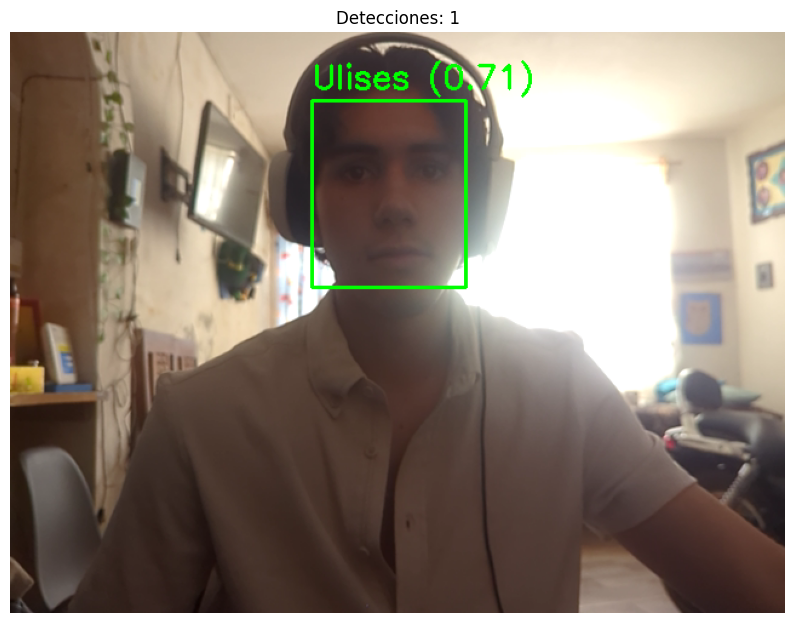

In [6]:
# Plot the final image with detections and predictions
import matplotlib.pyplot as plt
img = cv2.cvtColor(fframe, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis('off')
plt.title(f"Detecciones: {len(cached_predictions)}")
plt.show()